In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/raw/customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Question 1: What is the shape, structure, and data health of the dataset?

In [16]:
# 1. Dimensions & schema
print("shape (Rows, Columns): ", df.shape)

shape (Rows, Columns):  (7043, 21)


In [17]:
print("\nData Types & Non-null counts:" )
df.info()


Data Types & Non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043

In [ ]:
# Convert empty spaces to NaN and cast to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'].str.strip(), errors='coerce')
print("Actual missing in TotalCharges:", df['TotalCharges'].isnull().sum())

Actual missing in TotalCharges: 11


In [19]:
print("\nData Types & Non-null counts:" )
df.info()


Data Types & Non-null counts:
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043

In [20]:
# 2. Missing values overview
missing_count = df.isnull().sum()
missing_pct = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage (%)': missing_pct.round(2)
})

# Filter only columns with missing values > 0
missing_cols = missing_summary[missing_summary['Missing Values'] > 0]


if not missing_cols.empty:
    print("\nMissing Values Summary:")
    print(missing_cols.sort_values(by='Missing Values', ascending=False))
else:

    print("\nNo missing values found in the dataset!")


Missing Values Summary:
              Missing Values  Percentage (%)
TotalCharges              11            0.16


In [21]:
# 3. Duplicate check & Unique value counts per feature
print("\nDuplicate Rows:", df.duplicated().sum())
print("\nUnique Values per column:\n", df.nunique())


Duplicate Rows: 0

Unique Values per column:
 customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6530
Churn                  2
dtype: int64


Question 2: How are numerical features distributed, and are there severe outliers?

In [22]:
# 1. Summary statistics (Mean, Std, Min, Max, Quantiles)
print("Numerical Summary:\n", df.describe())

Numerical Summary:
        SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [ ]:
# 2. Skewness check
num_cols = df.select_dtypes(include=[np.number]).columns
print("\nFeature Skewness:\n", df[num_cols].skew())


Feature Skewness:
 SeniorCitizen     1.833633
tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64


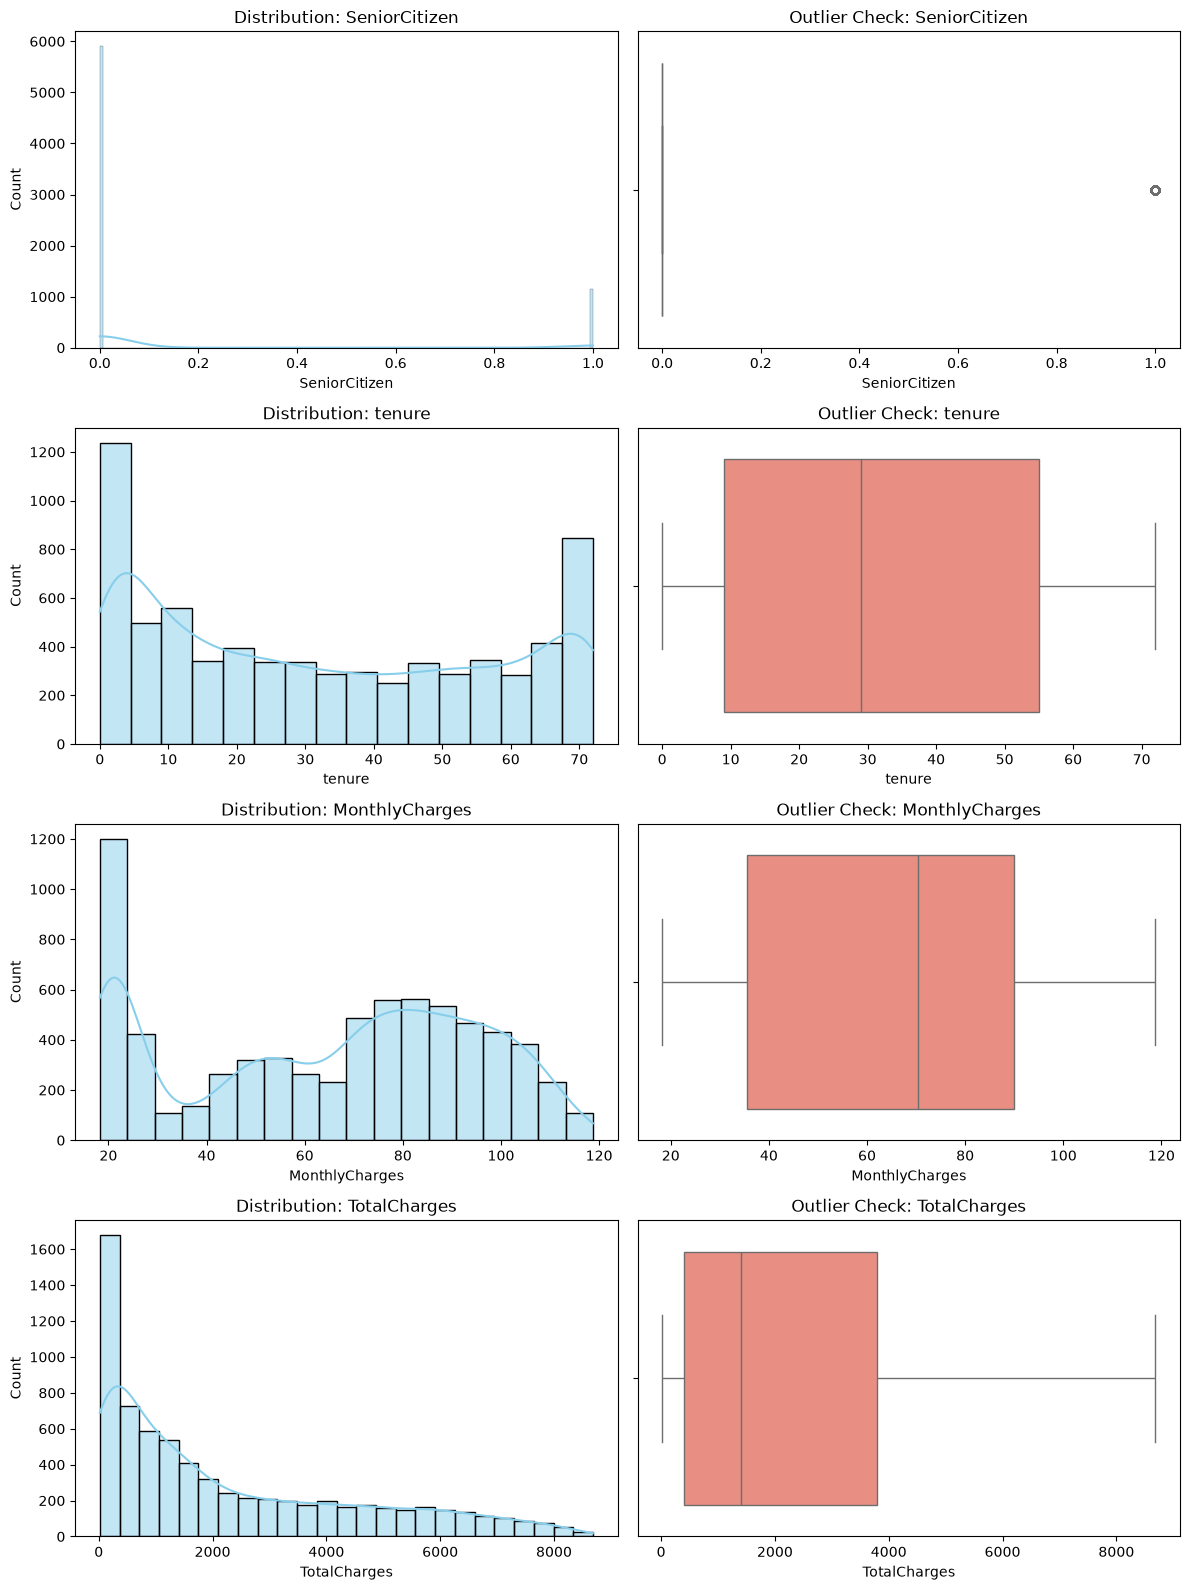

In [24]:
# 3. Visualizing distributions & outliers (Histograms + Boxplots)
fig, axes = plt.subplots(len(num_cols), 2, figsize=(12, 4 * len(num_cols)))
for i, col in enumerate(num_cols):
    # Histogram
    sns.histplot(df[col], kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Distribution: {col}')
    
    # Boxplot for Outliers
    sns.boxplot(x=df[col], ax=axes[i, 1], color='salmon')
    axes[i, 1].set_title(f'Outlier Check: {col}')

plt.tight_layout()
plt.show()

In [25]:
# 4. Calculating IQR-based Outlier Counts

numerical_cols = df.select_dtypes(include=np.number).columns

outlier_summary = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outlier_summary.append({
        "Feature": col,
        "Outlier Count": len(outliers),
        "Outlier %": round(len(outliers) / len(df) * 100, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2)
    })

outlier_summary = pd.DataFrame(outlier_summary)

outlier_summary

,Feature,Outlier Count,Outlier %,Lower Bound,Upper Bound
0,SeniorCitizen,1142,16.21,0.00,0.00
1,tenure,0,0.00,-60.00,124.00
2,MonthlyCharges,0,0.00,-46.02,171.38
3,TotalCharges,0,0.00,-4688.48,8884.67


Question 3: How are categorical features distributed, and is the target class imbalanced?


--- Value Counts for customerID ---
customerID
7590-VHVEG    1
5575-GNVDE    1
3668-QPYBK    1
7795-CFOCW    1
9237-HQITU    1
             ..
6840-RESVB    1
2234-XADUH    1
4801-JZAZL    1
8361-LTMKD    1
3186-AJIEK    1
Name: count, Length: 7043, dtype: int64
Proportions:
customerID
7590-VHVEG    0.014198
5575-GNVDE    0.014198
3668-QPYBK    0.014198
7795-CFOCW    0.014198
9237-HQITU    0.014198
                ...   
6840-RESVB    0.014198
2234-XADUH    0.014198
4801-JZAZL    0.014198
8361-LTMKD    0.014198
3186-AJIEK    0.014198
Name: proportion, Length: 7043, dtype: float64

--- Value Counts for gender ---
gender
Male      3555
Female    3488
Name: count, dtype: int64
Proportions:
gender
Male      50.47565
Female    49.52435
Name: proportion, dtype: float64

--- Value Counts for Partner ---
Partner
No     3641
Yes    3402
Name: count, dtype: int64
Proportions:
Partner
No     51.69672
Yes    48.30328
Name: proportion, dtype: float64

--- Value Counts for Dependents ---
Dependents

C:\Users\Acer\AppData\Local\Temp\ipykernel_27072\1246870095.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='Set2')


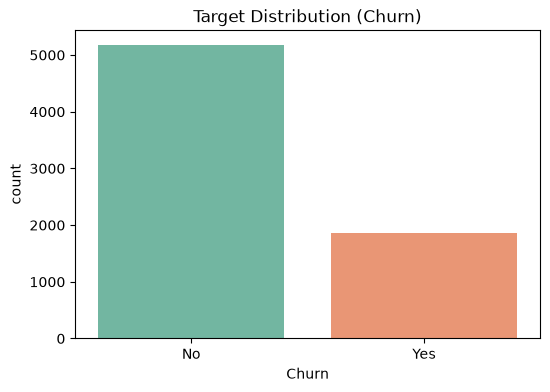

Class Imbalance Proportion:
 Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [26]:
cat_cols = df.select_dtypes(include=['object', 'category', 'str']).columns

# 1. Categorical value counts & proportion
for col in cat_cols:
    print(f"\n--- Value Counts for {col} ---")
    print(df[col].value_counts(dropna=False))
    print(f"Proportions:\n{df[col].value_counts(normalize=True, dropna=False) * 100}")

# 2. Target Class Imbalance Check
target_col = 'Churn'  
if target_col in df.columns:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col, palette='Set2')
    plt.title(f'Target Distribution ({target_col})')
    plt.show()
    print("Class Imbalance Proportion:\n", df[target_col].value_counts(normalize=True) * 100)

Question 4: How do features interact with each other and with the target variable?

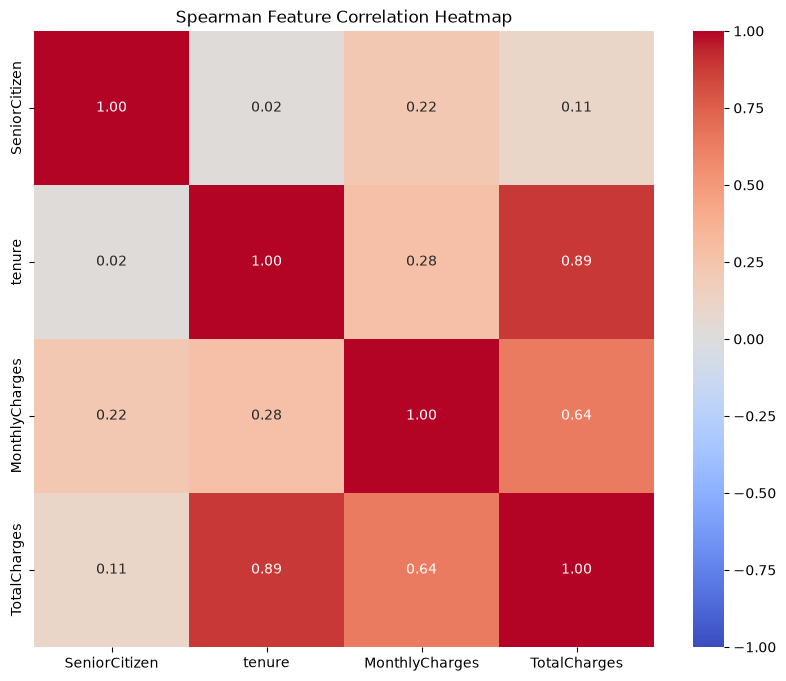

C:\Users\Acer\AppData\Local\Temp\ipykernel_27072\1378915205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set3')


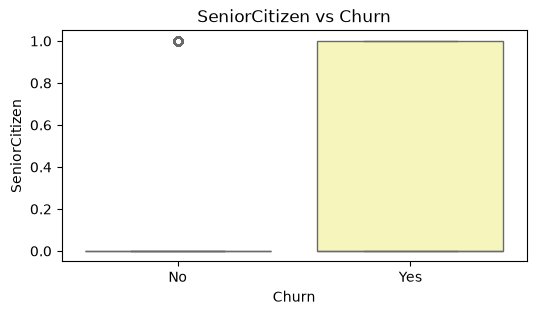

C:\Users\Acer\AppData\Local\Temp\ipykernel_27072\1378915205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set3')


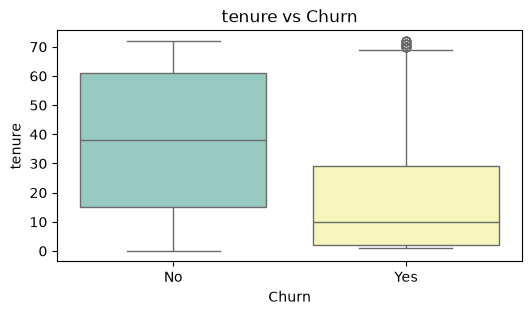

C:\Users\Acer\AppData\Local\Temp\ipykernel_27072\1378915205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set3')


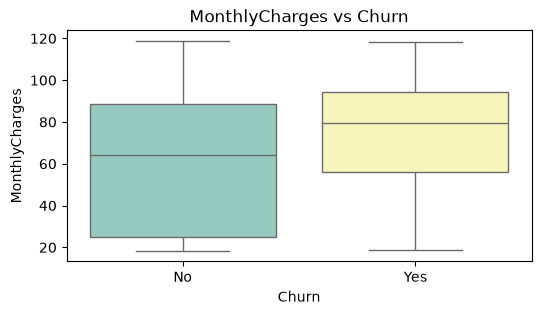

C:\Users\Acer\AppData\Local\Temp\ipykernel_27072\1378915205.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=target_col, y=col, data=df, palette='Set3')


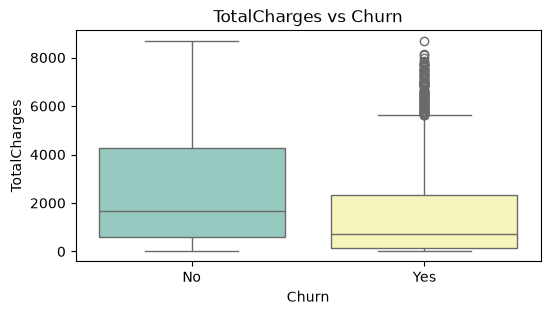

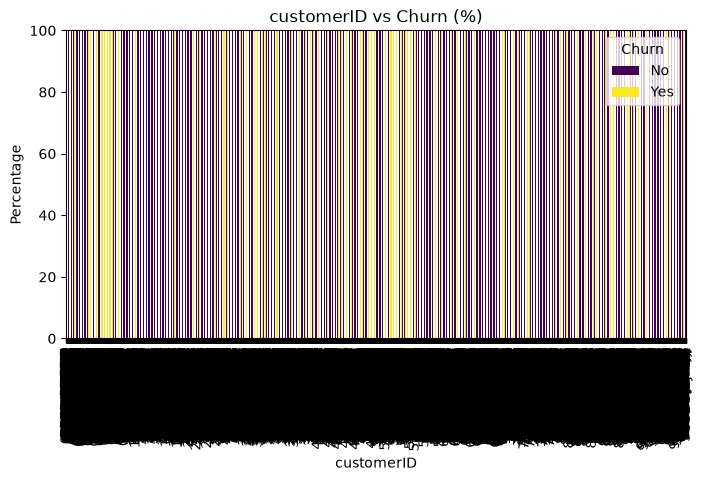

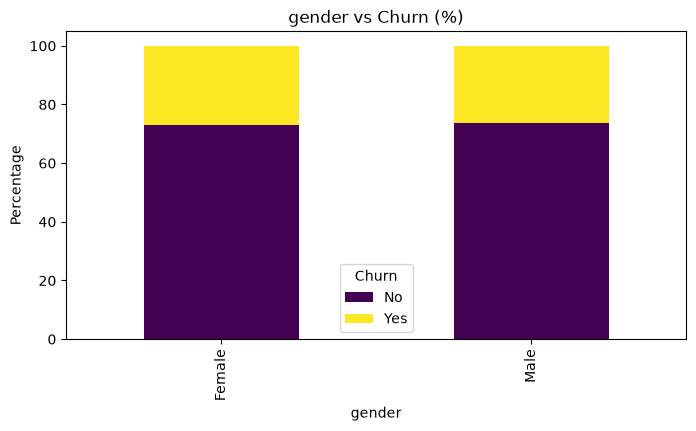

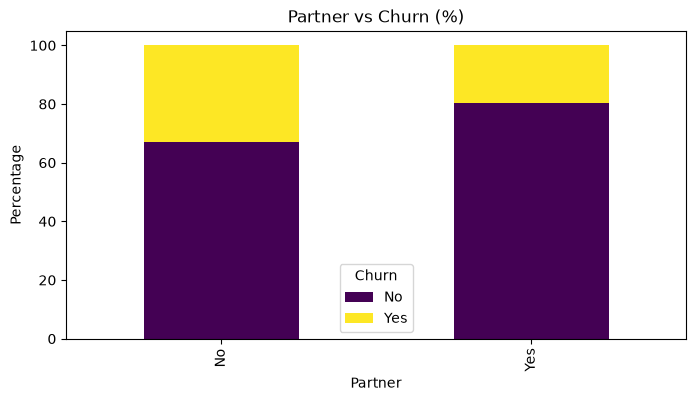

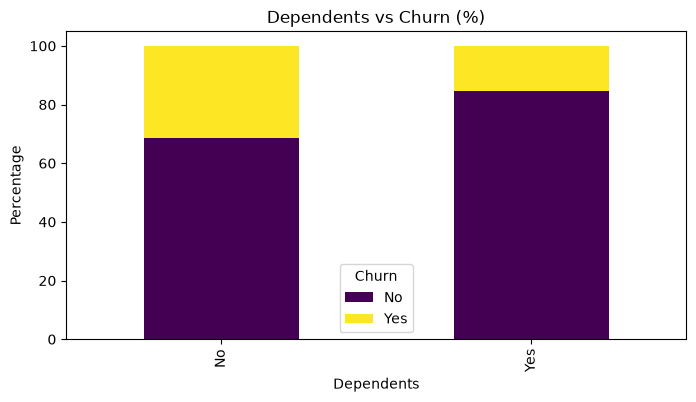

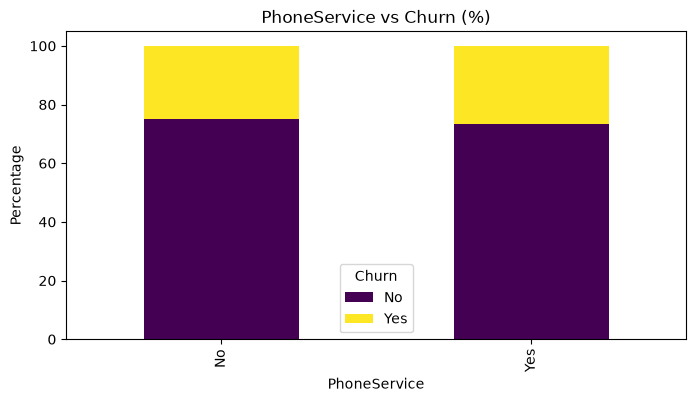

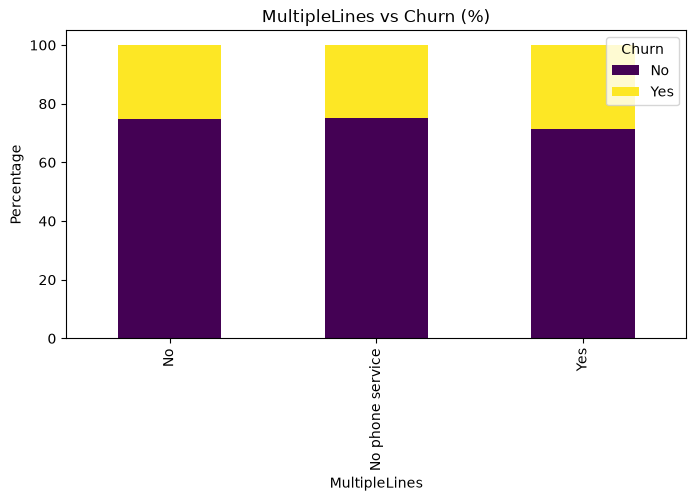

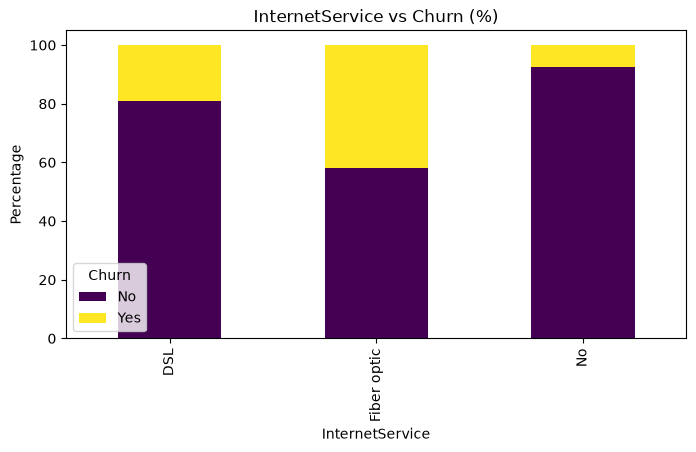

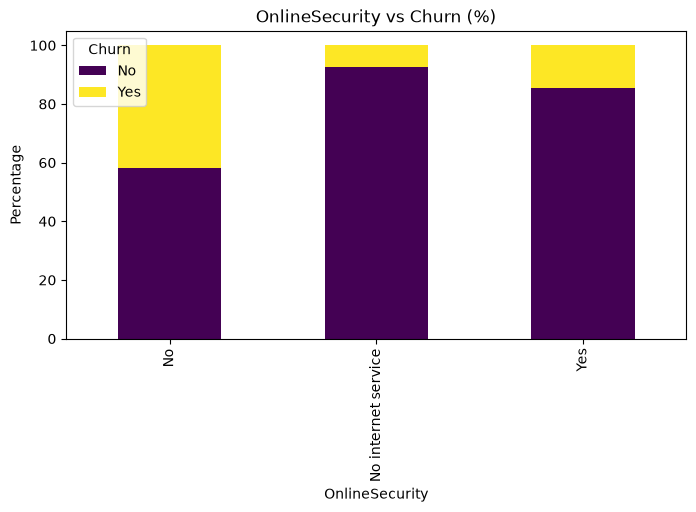

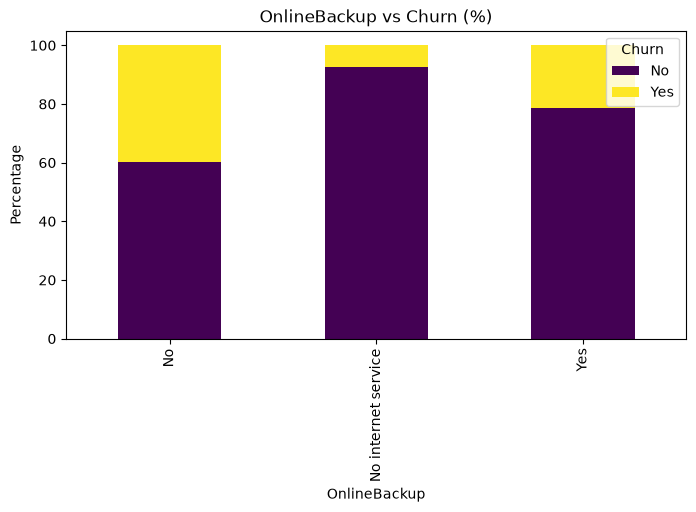

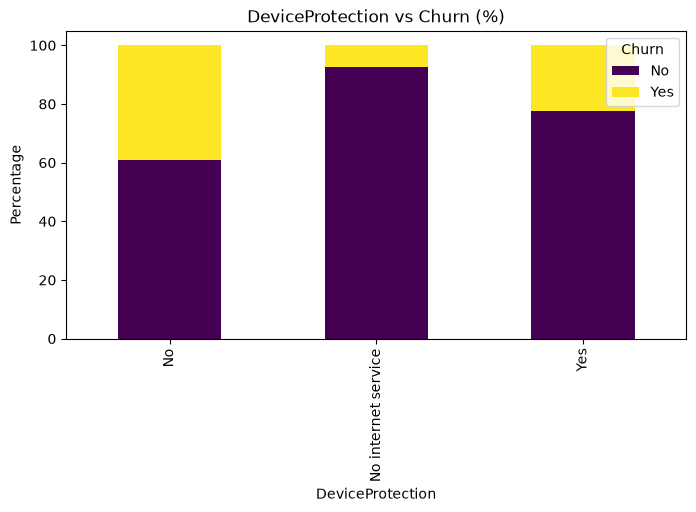

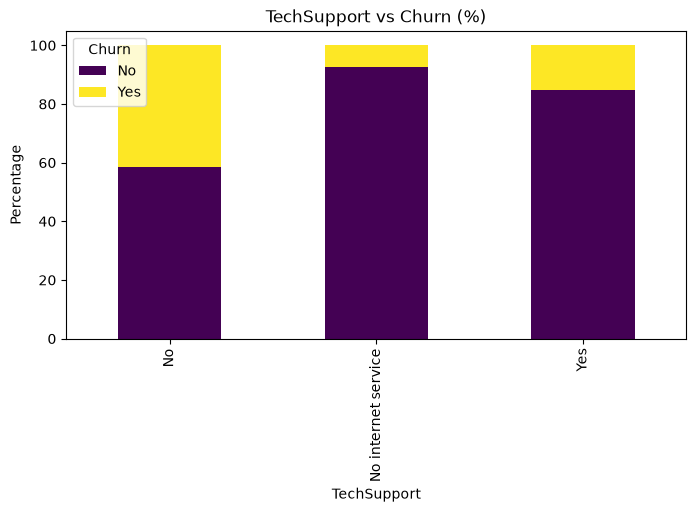

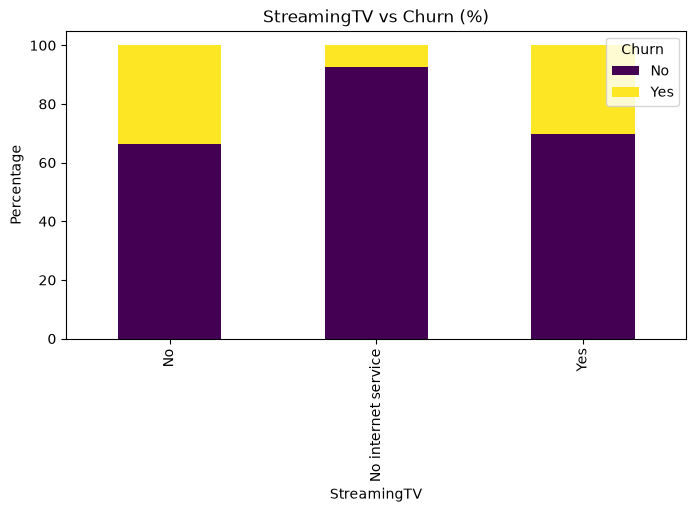

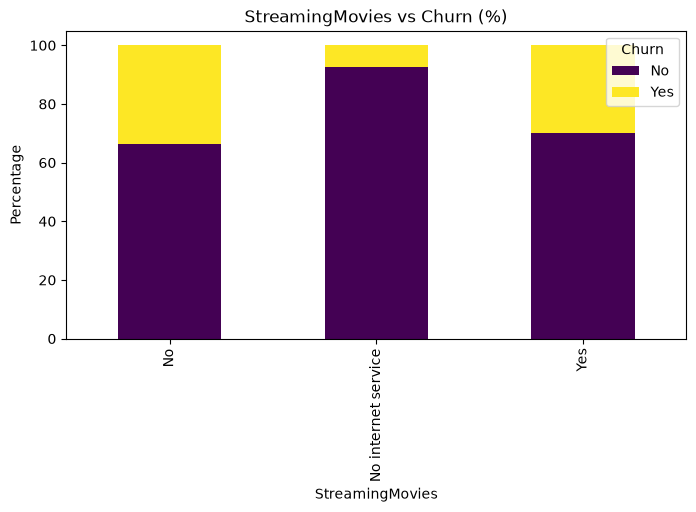

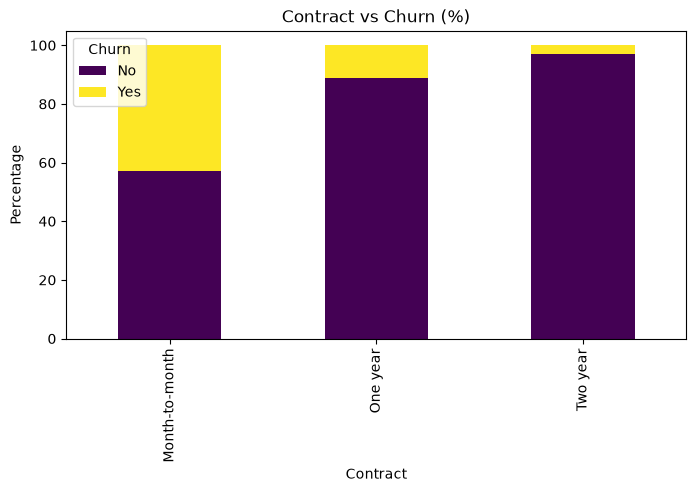

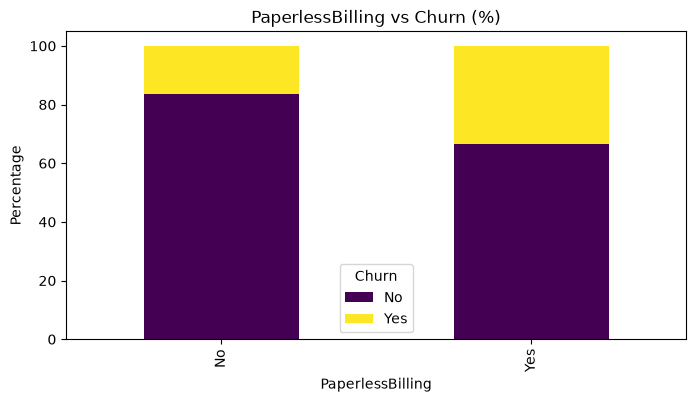

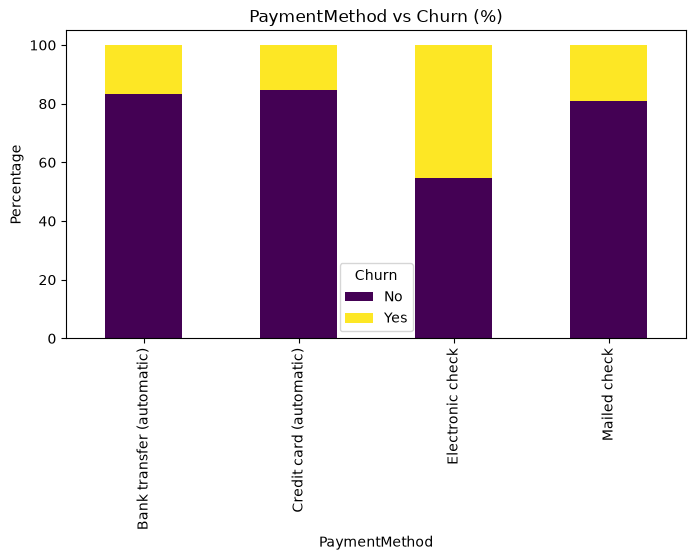

In [27]:
# 1. Correlation Matrix (Numerical Features)
plt.figure(figsize=(10, 8))
corr = df[num_cols].corr(method='spearman')  # Spearman handles non-linear relationships
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Spearman Feature Correlation Heatmap')
plt.show()

# 2. Numerical Features vs Target Variable (Bivariate Analysis)
if target_col in df.columns:
    for col in num_cols:
        plt.figure(figsize=(6, 3))
        sns.boxplot(x=target_col, y=col, data=df, palette='Set3')
        plt.title(f'{col} vs {target_col}')
        plt.show()

# 3. Categorical Features vs Target Variable (Cross-tabulation)
if target_col in df.columns:
    for col in cat_cols:
        if col != target_col:
            ct = pd.crosstab(df[col], df[target_col], normalize='index') * 100
            ct.plot(kind='bar', stacked=True, figsize=(8, 4), colormap='viridis')
            plt.title(f'{col} vs {target_col} (%)')
            plt.ylabel('Percentage')
            plt.show()

In [28]:
feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": df.nunique().values,
    "Missing Values": df.isnull().sum().values
})

feature_summary

,Feature,Data Type,Unique Values,Missing Values
0,customerID,str,7043,0
1,gender,str,2,0
2,SeniorCitizen,int64,2,0
3,Partner,str,2,0
4,Dependents,str,2,0
5,tenure,int64,73,0
6,PhoneService,str,2,0
7,MultipleLines,str,3,0
8,InternetService,str,3,0
9,OnlineSecurity,str,3,0


# EDA Findings

## 1. Data Quality

- **Dimensions**: The dataset contains 7,043 observations (rows) and 21 features (columns).
- **Identifier**: `customerID` is an arbitrary unique identifier (7,043 unique values) with no predictive value; it must be excluded from model training.
- **Missing Values**: 11 missing values (0.16%) were identified in `TotalCharges` after converting blank space strings (`' '`) to numeric values. All 11 records correspond to new customers with `tenure = 0`.
- **Data Type Corrections**: `TotalCharges` was loaded as an `object` type and converted to `float64`. `SeniorCitizen` is represented as integer `0/1` and functions as a binary categorical feature.
- **Duplicate Records**: 0 duplicate rows detected.

## 2. Target Variable Analysis

- **Target Column**: `Churn` (Binary: 'Yes' / 'No').
- **Class Distribution**:
  - **No Churn (`No`)**: 5,174 customers (73.46%)
  - **Churn (`Yes`)**: 1,869 customers (26.54%)
- **Imbalance Assessment**: The target variable has a moderate imbalance (~2.77:1 ratio).
- **Evaluation Strategy**: Accuracy will be deceptive and insufficient. Models must be evaluated using **ROC-AUC, PR-AUC, F1-Score, Precision, and Recall**, supported by Stratified K-Fold cross-validation and class weighting (`class_weight='balanced'`).

## 3. Numerical Features Distribution & Outliers

- **`tenure`**: Exhibits a bimodal distribution with heavy concentrations at extreme ends—new customers (1–5 months, peak churn hazard) and long-standing loyal customers (65–72 months). Median = 29.0 months, Mean = 32.37 months, Skewness = 0.24 (fairly symmetric).
- **`MonthlyCharges`**: Shows a multimodal distribution with a sharp spike at low charges ($18.25–$25.00 for basic phone-only plans) and a wide cluster between $70.00–$100.00 for multi-service/fiber optic subscribers. Median = $70.35, Mean = $64.76, Skewness = -0.22.
- **`TotalCharges`**: Strongly right-skewed distribution tapering off towards $8,685. Median = $1,397.48, Mean = $2,283.30, Skewness = 0.96.
- **Skewness & Outlier Analysis**:
  - Under the standard $1.5 \\times \\text{IQR}$ rule, there are **0 statistical outliers** in continuous features (`tenure`, `MonthlyCharges`, and `TotalCharges`).
  - `SeniorCitizen` flags 1,142 values as outliers solely because it is a binary indicator with a 16.2% minority class.
  - No aggressive outlier removal or clipping is required.

## 4. Categorical Features & Churn Patterns

- **High-Risk Indicators**:
  - **Contract Type**: Strongest driver of churn. Month-to-month contracts exhibit a **42.71% churn rate**, compared to **11.27%** for 1-year and only **2.83%** for 2-year contracts.
  - **Internet Service**: Fiber optic subscribers have a **41.89% churn rate**, significantly higher than DSL (**18.96%**) and customers with no internet (**7.40%**).
  - **Payment Method**: Electronic check users churn at **45.29%**, compared to ~15–19% for automated payments (bank transfer, credit card) and mailed checks.
  - **Add-on Services**: Lack of tech support (**41.64%** vs **15.17%** with support) and online security (**41.77%** vs **14.61%** with security) are strongly linked to elevated churn.
  - **Paperless Billing**: Customers with paperless billing churn at **33.57%** vs **16.33%** for traditional billing.
- **Low-Impact / Neutral Features**:
  - **`gender`**: Virtually zero difference (Female: 26.92%, Male: 26.16%).
  - **`PhoneService`**: Churn rates are comparable (Yes: 26.71%, No: 24.93%).
- **Multi-Level Dependencies**: Features like `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `StreamingTV`, and `StreamingMovies` share the sub-category `'No internet service'`, which should be handled systematically during one-hot encoding.

## 5. Feature Relationships & Bivariate Insights

- **Multicollinearity**: `TotalCharges` has a very strong monotonic correlation with `tenure` (Spearman $\\rho = 0.89$, Pearson $r = 0.83$) and a moderate-to-high correlation with `MonthlyCharges` (Spearman $\\rho = 0.64$).
- **Churner vs. Non-Churner Profile**:
  - **Tenure**: Churners leave early (Median tenure = **10.0 months** vs **38.0 months** for non-churners).
  - **Monthly Spend**: Churners pay higher monthly fees (Median = **$79.65** vs **$64.43** for non-churners), driven by fiber optic and non-bundled add-ons.
  - **Total Spend**: Due to short lifespans, churners have lower median total spend (Median = **$703.55** vs **$1,683.60** for non-churners).

## 6. Overall EDA Conclusion & Modeling Recommendations

The dataset contains clear, high-signal patterns for customer churn prediction.

### Recommended Modeling & Preprocessing Pipeline:
1. **Drop `customerID`**: Uninformative high-cardinality identifier.
2. **Handle `TotalCharges` Missing Values**: Impute the 11 missing values with `0` (since `tenure = 0` implies no prior billing) or median.
3. **Encoding Strategy**:
   - Binary encoding for 2-level categorical features (`Partner`, `Dependents`, `PhoneService`, `PaperlessBilling`, `gender`).
   - One-Hot Encoding for nominal multi-class features (`InternetService`, `Contract`, `PaymentMethod`, `MultipleLines`, and internet service add-ons).
4. **Feature Scaling**: Apply `StandardScaler` / `RobustScaler` on numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) for distance-based and regularized models (Logistic Regression, SVM, KNN).
5. **Class Imbalance & Validation Strategy**:
   - Employ **Stratified K-Fold Cross-Validation** to preserve class ratios.
   - Use cost-sensitive loss (`class_weight='balanced'`) for tree-based models, Logistic Regression, and SVM.
   - Primary evaluation metrics: **ROC-AUC, PR-AUC, Recall, and F1-Score**.